In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/yasserh/wine-quality-dataset/WineQT.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/yasserh/wine-quality-dataset/WineQT.csv")
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595


In [3]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import math
import cupy as cp
import matplotlib.pyplot as plt

In [4]:
print(cp.__version__)
print(cp.cuda.runtime.getDeviceCount())

14.0.1
2


In [5]:
x = df[df.columns.drop(["Id", "quality"])]
y = df["quality"]
x,y

(      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
 0               7.4             0.700         0.00             1.9      0.076   
 1               7.8             0.880         0.00             2.6      0.098   
 2               7.8             0.760         0.04             2.3      0.092   
 3              11.2             0.280         0.56             1.9      0.075   
 4               7.4             0.700         0.00             1.9      0.076   
 ...             ...               ...          ...             ...        ...   
 1138            6.3             0.510         0.13             2.3      0.076   
 1139            6.8             0.620         0.08             1.9      0.068   
 1140            6.2             0.600         0.08             2.0      0.090   
 1141            5.9             0.550         0.10             2.2      0.062   
 1142            5.9             0.645         0.12             2.0      0.075   
 
       free su

In [6]:
xtrain, xtest, ytrain, ytest = train_test_split(x,y, random_state=42, test_size=0.2)

In [7]:
np.random.seed(43)
a = np.full(len(xtrain), 0)
b = np.random.rand()

In [8]:
gama = 1

In [9]:
k = lambda xt,x : np.exp(-gama*(xt-x)**2)
# k(xtrain, xtest.iloc[0])

In [10]:
# z = lambda xt, x, yt : sum(a * yt * k(xt,x))
# z(xtrain, xtest.iloc[0], ytrain)

In [11]:
q = lambda yi, yj, xi,xj : yi*yj*k(xi,xj)

In [12]:
yt = lambda t, y : 1 if t==y else -1

In [13]:
yp = lambda xt, x, yt: 1 if z(xt,x,yt)>0 else -1

In [14]:
da = lambda x,y : x.apply(lambda xi : x.apply( lambda xj : q(y.loc[xi.name],y.loc[xj.name],xi,xj), axis =1), axis=1)*a - 1

In [15]:
# da(xtrain,ytrain)

In [16]:
def train(yt, learning_rate=0.01):
    global a
    greda = np.sum(xtrain.apply(lambda x : da(xtrain, x, yt.loc[x.name]), axis=1), axis=0)
    mask = xtrain.apply(lambda x:yp(xtrain,x,ytrain), axis=1)!=yt
    a[~mask] -= greda[~mask] * learning_rate
    # a -= greda * learning_rate

In [17]:
def loss(x,y):
    global a
    X = cp.asarray(x.to_numpy(), dtype=cp.float32)
    Y= cp.asarray(y.to_numpy(), dtype=cp.float32)
    A = cp.asarray(a, dtype=cp.float32)

    sqnorms = cp.sum(X**2, axis=1)
    K = cp.exp(-gama*(sqnorms[:,None]+sqnorms[None,:]-2*X@X.T))
    Q=(Y[:,None]*Y[None,:])*K
    loss = 0.5*(A@Q@A) -cp.sum(A)
    return loss

In [18]:
def predictone(X,y,a):
    X = cp.asarray(X)
    Y= cp.asarray(y)
    train = cp.asarray(xtrain)
    A = cp.asarray(a, dtype=cp.float32)

    sqx = cp.sum(X**2, axis=1)
    sqt = cp.sum(train**2, axis=1)
    K = cp.exp(-gama*(sqx[:,None]+sqt[None,:]-2*X@train.T))
    # print(K.shape, sqx.shape, sqt.shape, A.shape,Y.shape)
    scores = K@(A*Y)
    return np.where(scores>=0,1,-1)

In [19]:
def train(x,y,a,lr=0.01):
    X = cp.asarray(x.to_numpy(), dtype=cp.float32)
    Y = cp.asarray(y.to_numpy(), dtype=cp.float32)
    A = cp.asarray(a, dtype=cp.float32)

    sqnorms = cp.sum(X**2, axis=1)
    K = cp.exp(-gama * (sqnorms[:,None]+sqnorms[None,:]-2*X@X.T))
    Q = (Y[:,None]*Y[None,:])*K
    greadient=Q@A-1
    A-=greadient*lr
    A = cp.clip(A,0,5)
    a = A.get()
    return a

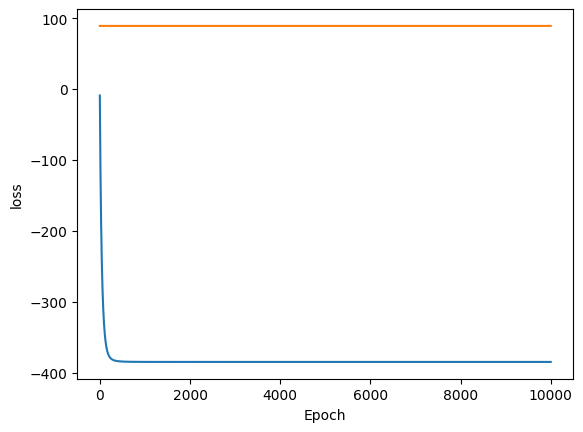

In [20]:
losses = []
acc = []
y6 = pd.Series(np.where(ytrain==7,1,-1), index=ytrain.index)
y6t = pd.Series(np.where(ytest==7,1,-1), index=ytest.index)
for i in range(10000):
    a=train(xtrain, y6,a)
    acc.append(accuracy_score(predictone(xtest,y6,a).get(), y6t))
    losses.append(float(loss(xtrain,y6)))
plt.plot(losses)
plt.plot(np.array(acc)*100)
plt.xlabel("Epoch")
plt.ylabel("loss")
plt.show()


In [21]:
type(a)

numpy.ndarray

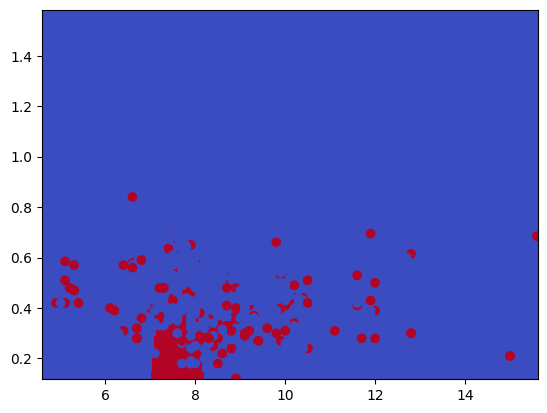

In [22]:
xx,yy = np.meshgrid(np.linspace(xtrain.iloc[:,0].min(), xtrain.iloc[:,0].max(), 300), np.linspace(xtrain.iloc[:,1].min(), xtrain.iloc[:,1].max(), 300))
grid = np.zeros((xx.size, xtrain.shape[1]))
grid[:,0] = xx.ravel()
grid[:,1]=yy.ravel()
grid[:,2:] = xtrain.iloc[:,2:].mean().values
Z = predictone(grid,y6,a).reshape(xx.shape)
plt.pcolormesh(xx,yy,Z.get(),cmap="coolwarm", shading="auto")
plt.scatter(xtrain.iloc[:,0], xtrain.iloc[:,1], c=y6, cmap="coolwarm")

In [23]:
y6t = pd.Series(np.where(ytest==7,1,-1), index=ytest.index)
print(np.asarray(accuracy_score(predictone(xtest,y6,a).get(), y6t))*100)

89.08296943231441


In [24]:
def predict(a,x):
    y = cp.asarray(ytrain.to_numpy())
    uy = cp.unique(y)
    yc = cp.stack([cp.where(y==i, 1,-1) for i in uy])
    Xt = cp.asarray(xtrain.to_numpy(), dtype = cp.float32)
    X = cp.asarray(x.to_numpy(), dtype=cp.float32)

    sqx = cp.sum(X**2, axis=1)
    sqt = cp.sum(Xt**2, axis=1)
    K = cp.exp(-gama*(sqx[:,None]+sqt[None,:]-2*X@Xt.T))

    # print(K.shape, a.shape, yc.shape)

    ay = a * yc
    z = ay@K.T
    # return cp.argmax(z)
    # return cp.stack((cp.argmax(z, axis=0), cp.arange(z.shape[1])), axis=1)
    z = cp.argmax(z,axis=0)
    return uy[z]

In [25]:
def multitrain(epoch, lr=0.01):
    y = cp.asarray(ytrain.to_numpy())
    yt = cp.asarray(ytest.to_numpy())
    uy = cp.unique(y)
    yc = cp.stack([cp.where(y==i,1,-1) for i in uy])
    ac = cp.zeros_like(yc, dtype=cp.float32)
    print(y.shape, uy.shape, yc.shape, ac.shape)
    X = cp.asarray(xtrain.to_numpy(), dtype=cp.float32)

    sqx = cp.sum(X**2, axis=1)
    print(sqx.shape)
    K = cp.exp(-gama * (sqx[:,None] + sqx[None,:] - 2*X@X.T))
    print(K.shape)
    losses = []
    acc=[]
    acct = []
    
    for i in range(epoch):
        ay = ac * yc
        kay = ay@K

        da = yc*kay-1
        ac-= lr*da
        ac = cp.clip(ac,0,5)

        acc.append(accuracy_score(predict(ac,xtrain).get(), y.get()))
        acct.append(accuracy_score(predict(ac,xtest).get(), yt.get()))

        loss = 0.5*cp.sum(ay*kay,axis=1) - cp.sum(ac)
        losses.append(loss)
    return ac, losses,np.asarray(acc)*100, np.asarray(acct)*100
    # return ac

(914,) (6,) (6, 914) (6, 914)
(914,)
(914, 914)


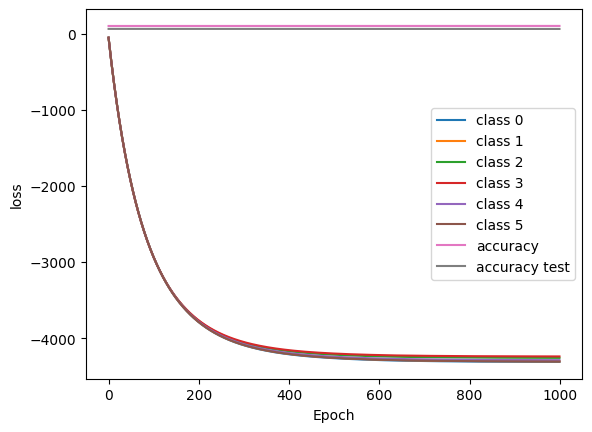

In [26]:
A,losses, acc, acct = multitrain(1000)
losses = cp.asnumpy(cp.stack(losses))
for i in range(6):
    plt.plot(losses[:,i], label=f"class {i}")

plt.plot(acc, label="accuracy")
plt.plot(acct, label="accuracy test")
plt.xlabel("Epoch")
plt.ylabel("loss")
plt.legend()
plt.show()
# print(acct)